## c2 w1 p4

### Gradient Descent

* Gradient Descent là một thuật toán tối ưu hoá (optimization algorithm) mạnh mẽ, sử dụng rộng rãi trong các bài toán Machine Learning đơn giản đến phức tạp. Gradient Descent và các biến thể của nó được sử dụng linh hoạt, hiệu quả với nhiều model function và cost function khác nhau tuỳ vào từng trường hợp.

* Cốt lõi của Gradient Descent là bài toán tối thiểu hoá cost thông qua cập nhật trọng số với gradient.
    $$
        \theta = \theta -\alpha \nabla_{\theta}J \rightarrow \min_\theta J(\theta)
    $$
    - $\theta$ - parameters
    - $\alpha$ - learning rate
    - $\nabla_{\theta}J$ - gradient theo $\theta$

* Sự thay đổi
    - Hướng thay đổi phụ thuộc vào dấu của $\nabla_{\theta}J$
    - Biên độ thay đổi phụ thuộc vào $\nabla_{\theta}J$ và $\alpha$

* Lưu ý rằng phép cập nhật các param phải được thực hiện "đồng thời".  
    $
    \text{Loops until convergence}
    \begin{cases}
        w = w - \alpha \frac{\partial}{\partial w}J(w,b) \\
        b = b - \alpha \frac{\partial}{\partial b}J(w,b) \\
    \end{cases}
    $

    |simultaneously (True)|sequently (False)|
    |--|--|
    |w_old, b_old => w_new|w_old, b_old => w_new|
    |w_old, b_old => b_new|w_new, b_old => b_new|

* Learning Rate
    - learning rate too small => tiny step - too slow, inefficient
    - learning rate too large => huge step - failed/not convergence/divergence

* Với fixed learning rate (không bị phân kỳ), càng về local minima:  
    -> derivative càng nhỏ -> step càng nhỏ -> ngày càng tiến về minima  
    -> khi đến đáy, derivative bằng 0, param không còn bị thay đổi

* "Batch" Gradient Descent  
each step of gradient descent uses all the training examples.

#### Gradient Descent for Linear Regression Algorithm

* Với Linear Regression Algorithm sử dụng Univariate Linear Model và MSE.
    $$
    \begin{cases}
        w = w - \alpha \frac{\partial}{\partial w}J(w,b) \\
        b = b - \alpha \frac{\partial}{\partial b}J(w,b) 
    \end{cases}

    =

    \begin{cases}
        w = w - \alpha \frac{\partial}{\partial w} \left(\frac{1}{2m}\sum_{i=1}^m(f_{w,b}(x^{(i)}) - y^{(i)})^2\right) \\
        b = b - \alpha \frac{\partial}{\partial b} \left(\frac{1}{2m}\sum_{i=1}^m(f_{w,b}(x^{(i)}) - y^{(i)})^2\right) \\
    \end{cases}
    $$

* Với $f_{w,b}(x^{(i)}) = wx^{(i)} + b$
    $$
    \begin{cases}
        w = w - \alpha \frac{\partial}{\partial w} \left(\frac{1}{2m}\sum_{i=1}^m(wx^{(i)} + b - y^{(i)})^2\right) \\
        b = b - \alpha \frac{\partial}{\partial b} \left(\frac{1}{2m}\sum_{i=1}^m(wx^{(i)} + b - y^{(i)})^2\right) \\
    \end{cases}

    =

    \begin{cases}
        w = w - \alpha \left(\frac{1}{m} \sum_{i=1}^{m} (wx^{(i)} + b - y^{(i)}) x^{(i)}\right) \\
        b = b - \alpha \left(\frac{1}{m} \sum_{i=1}^{m} (wx^{(i)} + b - y^{(i)})\right) \\
    \end{cases}
    $$

### Building Gradient Descent for House Price Prediction problem

#### Problem

|set|values|
|--|--|
|Size (1000 sqft) |1.0, 1.7, 2.0, 2.5, 3.0, 3.2|
|Price (1000s of dollars) |250, 300, 480, 430, 630, 730|

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480, 430, 630, 730])

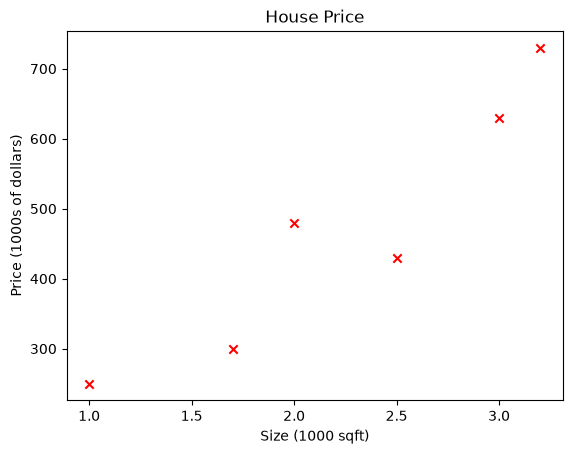

In [2]:
plt.scatter(x_train, y_train, c='red', marker='x')

plt.title("House Price")
plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (1000s of dollars)")

plt.show()

#### Building model

In [3]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    predict = x * w + b
    error = y - predict
    cost = 1 / (2 * m) * np.sum(error ** 2)

    return cost


In [4]:
# Ideals params are w = 209 and b = 2.4
cost = compute_cost(x_train, y_train, w = 209, b = 2.4)
print(f"{cost:.4f}")

1736.2683


In [5]:
def compute_gradients(x, y, w, b):
    m = x.shape[0]
    error = w * x + b - y

    dl_dw = 1 / m * np.sum(error * x)
    dl_db = 1 / m * np.sum(error)

    return dl_dw, dl_db

In [6]:
gradients = compute_gradients(x_train, y_train, w = 100, b = 100)
print(gradients)

(np.float64(-390.5), np.float64(-146.66666666666666))


In [7]:
def gradient_descent(x, y, w, b, lr = 0.01, iter = 10000, graph = False):

    history_params = []
    history_cost = []

    while(iter):
        iter -= 1
        gradients = compute_gradients(x, y, w, b)
        w = w - lr * gradients[0]
        b = b - lr * gradients[1]

        history_params.append([w, b])
        history_cost.append(compute_cost(x, y, w, b))

    if (graph):
        return w, b, history_params, history_cost
    else:
        return w, b
    

In [8]:
w_init = 100
b_init = 100

lr = 0.01
iter = 10000

w_final, b_final, hist_params, hist_cost = gradient_descent(x_train, y_train, w=w_init, b=b_init, lr=lr, iter=iter, graph=True)
print(f"{w_final} - {b_final}")

cost_final = compute_cost(x_train, y_train, w_final, b_final)
print(cost_final)

209.35610807663573 - 2.4395127909794847
1735.8832191494478


#### Visualization

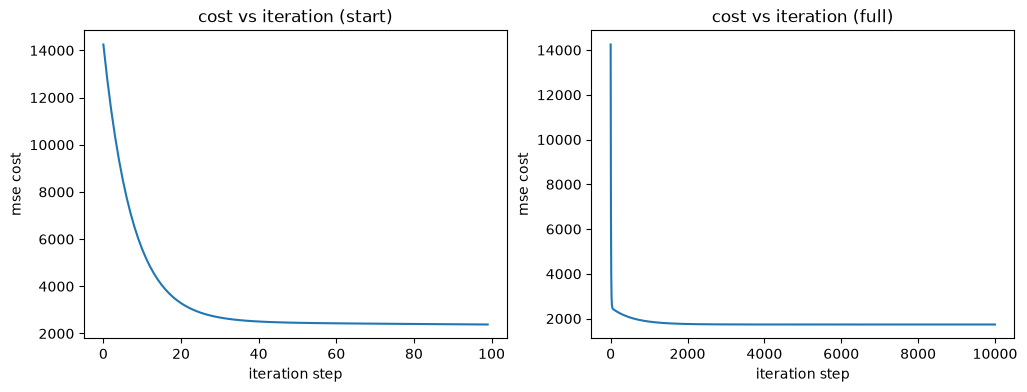

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

axes[0].plot(hist_cost[:100])
axes[0].set_title("cost vs iteration (start)")
axes[0].set_xlabel("iteration step")
axes[0].set_ylabel("mse cost")

axes[1].plot(hist_cost)
axes[1].set_title("cost vs iteration (full)")
axes[1].set_xlabel("iteration step")
axes[1].set_ylabel("mse cost")

plt.show()

In [10]:
hist_params[:5]

[[np.float64(103.905), np.float64(101.46666666666667)],
 [np.float64(107.55999627777778), np.float64(102.831455)],
 [np.float64(110.98117265652408), np.float64(104.1009671997963)],
 [np.float64(114.18366515027067), np.float64(105.28137800513596)],
 [np.float64(117.18162980362925), np.float64(106.3784623700619)]]

In [11]:
hist_w = [x[0] for x in hist_params]
hist_b = [x[1] for x in hist_params]

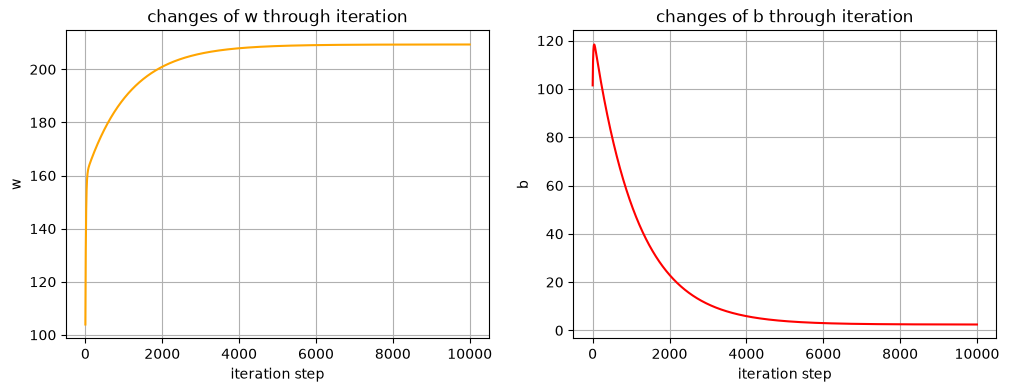

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
axes[0].plot(hist_w, c='orange')
axes[0].grid()
axes[0].set_title("changes of w through iteration")
axes[0].set_xlabel("iteration step")
axes[0].set_ylabel("w")

axes[1].plot(hist_b, c='red')
axes[1].grid()
axes[1].set_title("changes of b through iteration")
axes[1].set_xlabel("iteration step")
axes[1].set_ylabel("b")

plt.show()

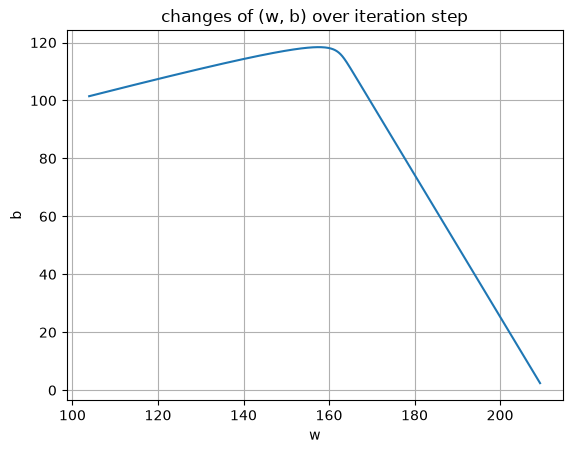

In [13]:
plt.plot(hist_w, hist_b)
plt.title("changes of (w, b) over iteration step")
plt.xlabel('w')
plt.ylabel('b')
plt.grid()
plt.show()

#### Evaluation & Prediction

In [14]:
print(f"final: {w_final} - {b_final}")
print(f"cost: {cost_final}")

final: 209.35610807663573 - 2.4395127909794847
cost: 1735.8832191494478


In [15]:
print(f"1000 sqft house prediction {w_final * 1.0 + b_final:.3f} Thousand dollars")
print(f"1200 sqft house prediction {w_final * 1.2 + b_final:.3f} Thousand dollars")
print(f"2000 sqft house prediction {w_final * 2.0 + b_final:.3f} Thousand dollars")

1000 sqft house prediction 211.796 Thousand dollars
1200 sqft house prediction 253.667 Thousand dollars
2000 sqft house prediction 421.152 Thousand dollars
